In [1]:
import pandas as pd 

In [2]:
data = pd.read_csv('data\powerconsumption.csv',encoding ='latin1')
data.shape
data['DateTime']=pd.to_datetime(data['Datetime'])


data["hour"] = data["DateTime"].dt.hour
data["day"] = data["DateTime"].dt.day
data["day_of_week"] = data["DateTime"].dt.dayofweek
data["month"] = data["DateTime"].dt.month

data.head(-10)

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,DateTime,hour,day,day_of_week,month
0,1/1/2017 0:00,6.559,73.80,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017-01-01 00:00:00,0,1,6,1
1,1/1/2017 0:10,6.414,74.50,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017-01-01 00:10:00,0,1,6,1
2,1/1/2017 0:20,6.313,74.50,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017-01-01 00:20:00,0,1,6,1
3,1/1/2017 0:30,6.121,75.00,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017-01-01 00:30:00,0,1,6,1
4,1/1/2017 0:40,5.921,75.70,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017-01-01 00:40:00,0,1,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52401,12/30/2017 21:30,7.950,70.20,0.082,0.062,0.085,35297.33840,30852.40871,16589.67587,2017-12-30 21:30:00,21,30,5,12
52402,12/30/2017 21:40,7.650,71.10,0.082,0.084,0.093,34591.63498,30347.95950,16485.95438,2017-12-30 21:40:00,21,30,5,12
52403,12/30/2017 21:50,8.140,69.73,0.081,0.062,0.085,34469.96198,29688.86161,16180.55222,2017-12-30 21:50:00,21,30,5,12
52404,12/30/2017 22:00,8.090,68.49,0.079,0.070,0.085,34920.15209,29445.84228,16053.78151,2017-12-30 22:00:00,22,30,5,12


In [5]:
data[data['PowerConsumption_Zone1']>43000].shape

(4521, 14)

In [ ]:
data.shape

(52416, 14)

In [ ]:
data["lag_1"] = data["PowerConsumption_Zone1"].shift(1)
data["lag_6"] = data["PowerConsumption_Zone1"].shift(6)
data["lag_24"] = data["PowerConsumption_Zone1"].shift(24)
data["lag_144"] = data["PowerConsumption_Zone1"].shift(144)

In [ ]:
data['target']=data['PowerConsumption_Zone1'].shift(-6)
data = data.dropna()
data.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,DateTime,hour,day,day_of_week,month,lag_1,lag_6,lag_24,lag_144,target
144,1/2/2017 0:00,11.01,75.8,0.076,0.033,0.163,26703.79747,18047.41641,17916.14458,2017-01-02 00:00:00,0,2,0,1,27748.86076,32117.46835,40283.54430,34055.69620,23629.36709
145,1/2/2017 0:10,10.74,77.3,0.078,0.084,0.108,26169.11392,17507.59878,17349.39759,2017-01-02 00:10:00,0,2,0,1,26703.79747,31357.97468,40216.70886,29814.68354,23118.98734
146,1/2/2017 0:20,10.47,78.2,0.078,0.088,0.130,25622.27848,17120.97264,16985.06024,2017-01-02 00:20:00,0,2,0,1,26169.11392,30701.77215,40477.97468,29128.10127,22736.20253
147,1/2/2017 0:30,10.31,79.2,0.076,0.091,0.134,24972.15190,16785.41033,16586.02410,2017-01-02 00:30:00,0,2,0,1,25622.27848,29681.01266,40611.64557,28228.86076,22049.62025
148,1/2/2017 0:40,10.63,79.3,0.079,0.037,0.152,24437.46835,16453.49544,16366.26506,2017-01-02 00:40:00,0,2,0,1,24972.15190,28830.37975,40435.44304,27335.69620,21855.18987


In [ ]:
X = data.drop(
    columns=["PowerConsumption_Zone1", "PowerConsumption_Zone2",
             "PowerConsumption_Zone3", "Datetime", "target","DateTime"]
)

y = data["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
from xgboost import XGBRegressor

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1747.1790815959203
RMSE: 2157.821273713803


In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

        Actual     Predicted
0  33331.11597  33126.484375
1  33765.95186  33355.476562
2  34188.18381  33735.906250
3  34314.22319  34616.660156
4  34673.43545  34916.824219
5  35013.74179  35323.164062
6  35505.29540  35639.382812
7  35599.82495  36162.140625
8  35492.69147  36360.777344
9  35940.13129  36821.203125


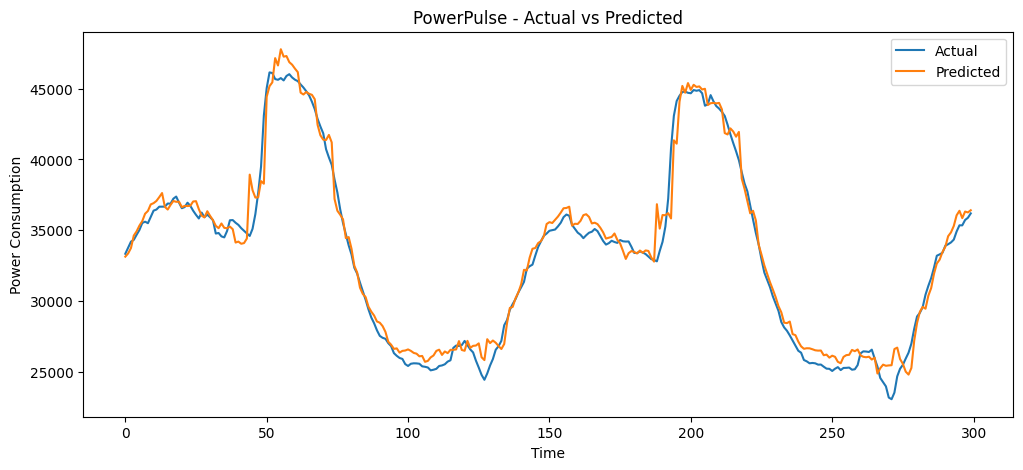

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")

plt.xlabel("Time")
plt.ylabel("Power Consumption")
plt.title("PowerPulse - Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)


R²: 0.8778187233335519


In [ ]:
print("Actual mean:", y_test.mean())
print("Actual min:", y_test.min())
print("Actual max:", y_test.max())

Actual mean: 29469.731452132197
Actual min: 17483.07692
Actual max: 46823.63239


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_pred = X_test["lag_6"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 3405.615557943371
Baseline RMSE: 4426.544484432355
Baseline R²: 0.48583396567539205


In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer.shap_values(X_test)

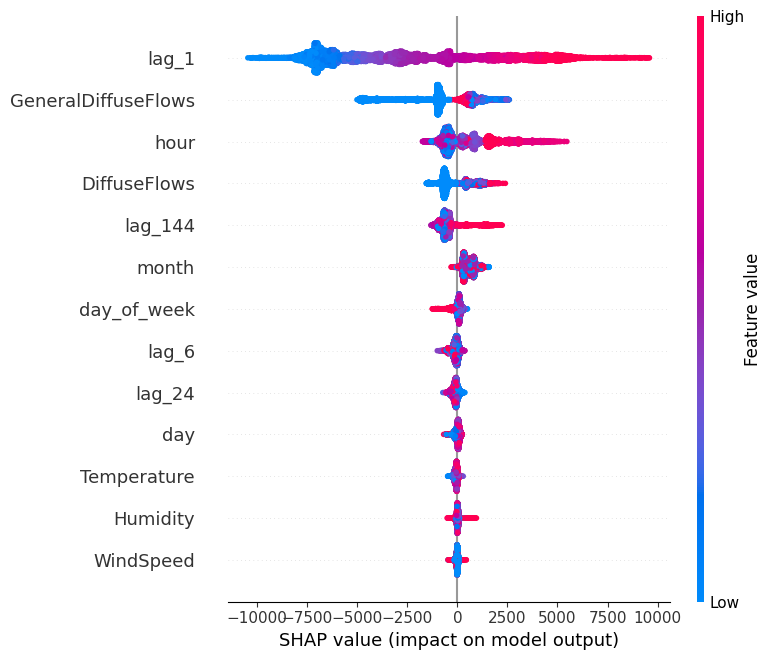

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

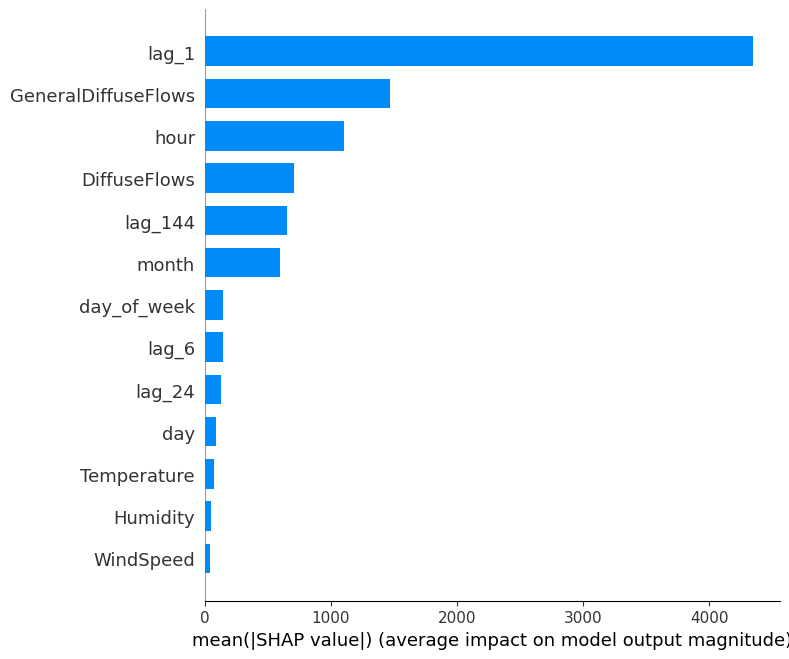

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

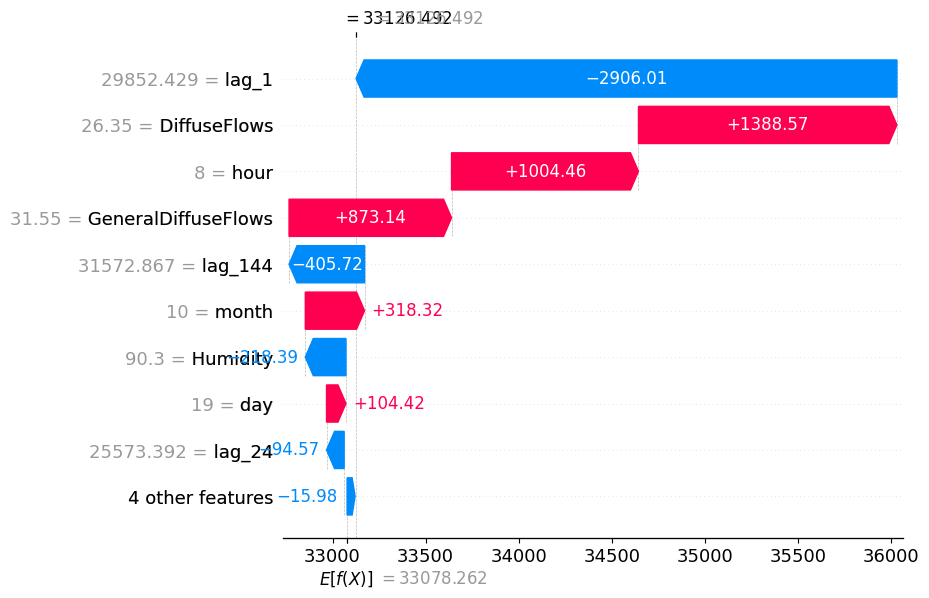

In [ ]:
row = X_test.iloc[[0]]
row_shap = explainer(row)
shap.plots.waterfall(row_shap[0])

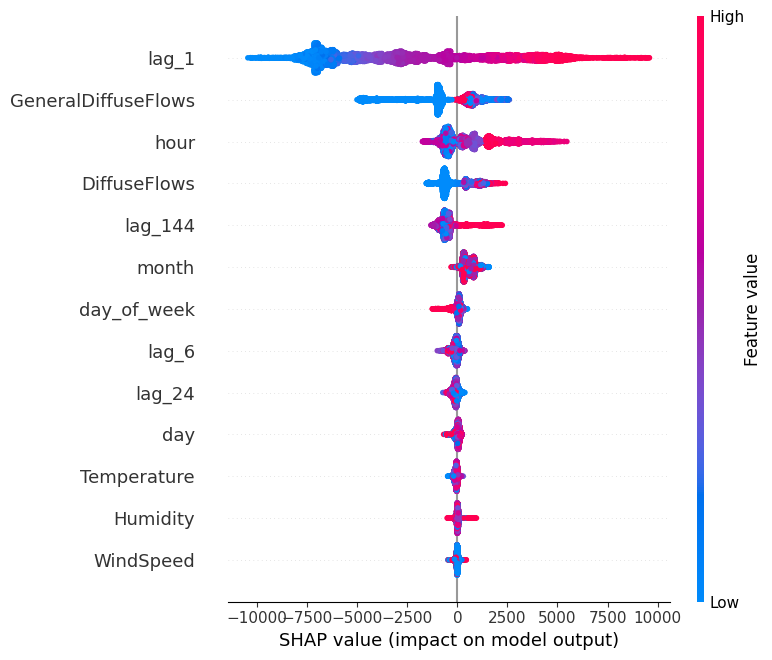

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
# Future electricity consumption: 1 hour ahead
data["future_consumption"] = data["target"]

# Remove rows where future consumption doesn't exist
data = data.dropna(subset=["future_consumption"])
data.shape

(52266, 20)

In [ ]:
split = int(len(data) * 0.8)

train_df = data.iloc[:split].copy()
test_df = data.iloc[split:].copy()
test_df.shape

(10454, 20)

In [ ]:
peak_threshold = train_df["future_consumption"].quantile(0.90)

print("Peak threshold:", peak_threshold)

Peak threshold: 43181.618143


In [ ]:
train_df["future_peak"] = (
    train_df["future_consumption"] >= peak_threshold
).astype(int)

test_df["future_peak"] = (
    test_df["future_consumption"] >= peak_threshold
).astype(int)

In [ ]:
print("Training class distribution:")
print(train_df["future_peak"].value_counts(normalize=True))

print("\nTesting class distribution:")
print(test_df["future_peak"].value_counts(normalize=True))

Training class distribution:
future_peak
0    0.899981
1    0.100019
Name: proportion, dtype: float64

Testing class distribution:
future_peak
0    0.988808
1    0.011192
Name: proportion, dtype: float64


In [ ]:
drop_columns = [
    "PowerConsumption_Zone1",
    "PowerConsumption_Zone2",
    "PowerConsumption_Zone3",
    "DateTime",
    "Datetime",
    "target",
    "future_consumption",
    "future_peak"
]

In [ ]:
X_train_peak = train_df.drop(columns=drop_columns)
y_train_peak = train_df["future_peak"]

X_test_peak = test_df.drop(columns=drop_columns)
y_test_peak = test_df["future_peak"]

In [ ]:
from xgboost import XGBClassifier

peak_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

peak_model.fit(
    X_train_peak,
    y_train_peak
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
y_peak_pred = peak_model.predict(X_test_peak)

y_peak_prob = peak_model.predict_proba(X_test_peak)[:, 1]
y_peak_prob

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Classification Report:")
print(classification_report(
    y_test_peak,
    y_peak_pred
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test_peak,
    y_peak_pred
))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10337
           1       0.48      0.91      0.63       117

    accuracy                           0.99     10454
   macro avg       0.74      0.95      0.81     10454
weighted avg       0.99      0.99      0.99     10454

Confusion Matrix:
[[10224   113]
 [   11   106]]


In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test_peak,
    y_peak_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8721702810780103


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:

    predictions = (
        y_peak_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test_peak,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test_peak,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test_peak,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.362 | Recall: 0.923 | F1: 0.520
Threshold: 0.4 | Precision: 0.416 | Recall: 0.915 | F1: 0.572
Threshold: 0.5 | Precision: 0.484 | Recall: 0.906 | F1: 0.631
Threshold: 0.6 | Precision: 0.563 | Recall: 0.880 | F1: 0.687
Threshold: 0.7 | Precision: 0.667 | Recall: 0.855 | F1: 0.749
Threshold: 0.8 | Precision: 0.779 | Recall: 0.812 | F1: 0.795
Threshold: 0.9 | Precision: 0.895 | Recall: 0.726 | F1: 0.802


In [ ]:
final_threshold = 0.9

y_peak_final = (
    y_peak_prob >= final_threshold
).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Final Peak Classification Report:")
print(classification_report(
    y_test_peak,
    y_peak_final
))

print("Final Confusion Matrix:")
print(confusion_matrix(
    y_test_peak,
    y_peak_final
))


Final Peak Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10337
           1       0.89      0.73      0.80       117

    accuracy                           1.00     10454
   macro avg       0.95      0.86      0.90     10454
weighted avg       1.00      1.00      1.00     10454

Final Confusion Matrix:
[[10327    10]
 [   32    85]]


In [ ]:
# anamoly detection 

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
test_pred.shape

(10454,)

In [ ]:
train_residual = y_train - train_pred
test_residual = y_test - test_pred

train_abs_residual = abs(train_residual)
test_abs_residual = abs(test_residual)

In [ ]:
residual_threshold = train_abs_residual.quantile(0.99)

print("Residual anomaly threshold:", residual_threshold)

Residual anomaly threshold: 2708.9721083625013


In [ ]:
residual_anomaly = (
    test_abs_residual > residual_threshold
).astype(int)
len(residual_anomaly)

10454

In [ ]:
print("Number of anomalies:", residual_anomaly.sum())
print("Anomaly percentage:", residual_anomaly.mean() * 100)

Number of anomalies: 1792
Anomaly percentage: 17.141763918117466


In [ ]:
anomaly_drop = [
    "Datetime",
    "DateTime",
    "target",
    "future_consumption",
    "future_peak"
]

In [ ]:
X_train_anomaly = X_train.drop(
    columns=anomaly_drop,
    errors="ignore"
)

X_test_anomaly = X_test.drop(
    columns=anomaly_drop,
    errors="ignore"
)
X_test_anomaly.shape

(10454, 13)

In [ ]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_train_anomaly)

,n_estimators,300
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [ ]:
iso_pred = iso_model.predict(X_test_anomaly)
iso_pred.shape

(10454,)

In [ ]:
iso_anomaly = (
    iso_pred == -1
).astype(int)

In [ ]:
print("Isolation Forest anomalies:", iso_anomaly.sum())
print(
    "Isolation Forest anomaly percentage:",
    iso_anomaly.mean() * 100
)

Isolation Forest anomalies: 161
Isolation Forest anomaly percentage: 1.5400803520183661


In [ ]:
print("Residual anomalies:", residual_anomaly.sum())
print("Isolation Forest anomalies:", iso_anomaly.sum())

Residual anomalies: 1792
Isolation Forest anomalies: 161


In [ ]:
print("Residual:", len(residual_anomaly))
print("Isolation Forest:", len(iso_anomaly))
print("Test DF:", len(test_df))

Residual: 10454
Isolation Forest: 10454
Test DF: 10454


In [ ]:
agreement = (
    (residual_anomaly == 1) &
    (iso_anomaly == 1)
)

print("Residual anomalies:", residual_anomaly.sum())
print("Isolation Forest anomalies:", iso_anomaly.sum())
print("Detected by both:", agreement.sum())

Residual anomalies: 1792
Isolation Forest anomalies: 161
Detected by both: 25


In [ ]:
anomaly_results = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Predicted": test_pred,
        "Residual": test_residual,
        "Residual_Anomaly": residual_anomaly,
        "IsolationForest_Anomaly": iso_anomaly
    },
    index=X_test.index
)
anomaly_results

,Actual,Predicted,Residual,Residual_Anomaly,IsolationForest_Anomaly
41956,33331.11597,33126.484375,204.631595,0,0
41957,33765.95186,33355.476562,410.475298,0,0
41958,34188.18381,33735.906250,452.277560,0,0
41959,34314.22319,34616.660156,-302.436966,0,0
41960,34673.43545,34916.824219,-243.388769,0,0
...,...,...,...,...,...
52405,31160.45627,31522.638672,-362.182402,0,0
52406,30430.41825,31550.925781,-1120.507531,0,0
52407,29590.87452,30867.515625,-1276.641105,0,0
52408,28958.17490,30518.226562,-1560.051662,0,0


In [ ]:
anomaly_results["DateTime"] = data.loc[
    anomaly_results.index, "DateTime"
]

anomaly_results["PowerConsumption"] = data.loc[
    anomaly_results.index,
    "PowerConsumption_Zone1"
]

In [ ]:
print(anomaly_results.shape)
print(anomaly_results.head())

(10454, 7)
            Actual     Predicted    Residual  Residual_Anomaly  \
41956  33331.11597  33126.484375  204.631595                 0   
41957  33765.95186  33355.476562  410.475298                 0   
41958  34188.18381  33735.906250  452.277560                 0   
41959  34314.22319  34616.660156 -302.436966                 0   
41960  34673.43545  34916.824219 -243.388769                 0   

       IsolationForest_Anomaly            DateTime  PowerConsumption  
41956                        0 2017-10-19 08:40:00       30262.05689  
41957                        0 2017-10-19 08:50:00       30772.51641  
41958                        0 2017-10-19 09:00:00       31938.38074  
41959                        0 2017-10-19 09:10:00       32429.93435  
41960                        0 2017-10-19 09:20:00       32770.24070  


In [ ]:
agreement = (
    (anomaly_results["Residual_Anomaly"] == 1) &
    (anomaly_results["IsolationForest_Anomaly"] == 1)
)

print("Detected by both:", agreement.sum())

Detected by both: 25


In [ ]:
anomaly_results["Anomaly_Score"] = (
    anomaly_results["Residual_Anomaly"] +
    anomaly_results["IsolationForest_Anomaly"]
)

In [ ]:
high_confidence = anomaly_results[
    anomaly_results["Anomaly_Score"] == 2
]

print(high_confidence)

            Actual     Predicted     Residual  Residual_Anomaly  \
46271  22621.53846  25393.351562 -2771.813103                 1   
46410  19790.76923  23759.003906 -3968.234676                 1   
46411  20227.69231  23273.193359 -3045.501049                 1   
46559  22012.30769  25213.501953 -3201.194263                 1   
47570  24098.46154  27879.066406 -3780.604866                 1   
47571  24172.30769  29038.765625 -4866.457935                 1   
47572  24480.00000  28973.195312 -4493.195312                 1   
48282  19777.94677  24772.458984 -4994.512214                 1   
48285  21110.26616  24654.621094 -3544.354934                 1   
48286  21633.46008  24636.230469 -3002.770389                 1   
48287  21943.72624  25074.617188 -3130.890948                 1   
48288  22527.75665  25582.478516 -3054.721866                 1   
48429  19704.94297  23686.863281 -3981.920311                 1   
48430  20057.79468  23025.931641 -2968.136961                 

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/forecast_model.pkl")
joblib.dump(peak_model, "models/peak_model.pkl")
joblib.dump(iso_model, "models/isolation_forest.pkl")

print("Models saved successfully!")

Models saved successfully!


In [ ]:
joblib.dump(residual_threshold, "models/residual_threshold.pkl")

['models/residual_threshold.pkl']

In [ ]:
print(X_train.columns.tolist())

['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'hour', 'day', 'day_of_week', 'month', 'lag_1', 'lag_6', 'lag_24', 'lag_144']


In [ ]:
print(X_train.shape)

(41812, 13)


In [7]:
sample = X_test.iloc[0]

print(sample.to_dict())
y_test.iloc[0]

NameError: name 'X_test' is not defined

In [ ]:
import json

print(json.dumps(sample.to_dict(), indent=2))

{
  "Temperature": 18.51,
  "Humidity": 90.3,
  "WindSpeed": 0.066,
  "GeneralDiffuseFlows": 31.55,
  "DiffuseFlows": 26.35,
  "hour": 8.0,
  "day": 19.0,
  "day_of_week": 3.0,
  "month": 10.0,
  "lag_1": 29852.42888,
  "lag_6": 27508.09628,
  "lag_24": 25573.39168,
  "lag_144": 31572.86652
}


In [ ]:
import joblib

joblib.dump(iso_model, "models/isolation_forest.pkl")

['models/isolation_forest.pkl']